# Prédiction de la demande horaire de vélos


Ce projet analyse les locations de vélos en libre-service pour estimer la demande à chaque heure. Une prévision agrégée peut aider à anticiper les périodes chargées et à organiser les opérations. L'objectif est de prédire `cnt`, le nombre de locations observées par heure, à partir du calendrier et des conditions météo.


## Jeu de données

Chaque ligne correspond à un relevé horaire. Les variables se répartissent en quatre groupes :

| Groupe | Colonnes | Rôle |
| --- | --- | --- |
| Repérage | `instant`, `dteday` | Index et date du relevé |
| Calendrier | `season`, `mnth`, `hr`, `holiday`, `weekday` | Saison, mois, heure et type de jour |
| Météo | `weathersit`, `temp`, `atemp`, `hum`, `windspeed` | Conditions, température, humidité et vent |
| Locations | `casual`, `registered`, `cnt` | Locations par type d'usager et total |

La cible `cnt` est la somme de `casual` et `registered`. Ces deux composantes ne seront pas utilisées comme variables prédictives : elles révéleraient directement la réponse.


## Approche


Le jeu de données contient à la fois les caractéristiques d'une heure et le nombre de locations correspondant. Il se prête donc à une **régression supervisée** : apprendre la relation entre les variables disponibles et une quantité numérique.


Le modèle vise directement `cnt`. Prédire séparément `casual` et `registered` serait une autre stratégie, mais elle ajouterait deux problèmes d'estimation sans être nécessaire pour cette première prévision agrégée.


## Outils et chargement


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## Data engineering : inspection des données


La première étape consiste à charger le CSV et à vérifier ses types, ses ordres de grandeur et ses valeurs manquantes avant l'exploration.


In [2]:
df = pd.read_csv("../data/velo.csv")
df.head()

,instant,dteday,season,mnth,hr,holiday,weekday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,1,0,0,6,1,9.84,14.395,81.0,0.0,3,13,16
1,2,2011-01-01,1,1,1,0,6,1,9.02,13.635,80.0,0.0,8,32,40
2,3,2011-01-01,1,1,2,0,6,1,9.02,13.635,80.0,0.0,5,27,32
3,4,2011-01-01,1,1,3,0,6,1,9.84,14.395,75.0,0.0,3,10,13
4,5,2011-01-01,1,1,4,0,6,1,9.84,14.395,75.0,0.0,0,1,1


In [3]:
df.dtypes

instant         int64
dteday         object
season          int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

In [4]:
df.describe()

,instant,season,mnth,hr,holiday,weekday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,15715.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,6.537775,11.546752,0.028770,3.003683,1.425283,20.376474,23.788755,62.774038,12.736540,35.676218,153.786869,189.463088
std,5017.0295,1.106918,3.438776,6.914405,0.167165,2.005771,0.639357,7.894801,8.592511,19.321135,8.196795,49.305030,151.357286,181.387599
min,1.0000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.820000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,4.000000,6.000000,0.000000,1.000000,1.000000,13.940000,16.665000,48.000000,7.001500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,7.000000,12.000000,0.000000,3.000000,1.000000,20.500000,24.240000,63.000000,12.998000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,10.000000,18.000000,0.000000,5.000000,2.000000,27.060000,31.060000,78.500000,16.997900,48.000000,220.000000,281.000000
max,17379.0000,4.000000,12.000000,23.000000,1.000000,6.000000,4.000000,41.000000,50.000000,100.000000,56.996900,367.000000,886.000000,977.000000


### Qualité des données


In [5]:
df.isnull().sum()

instant          0
dteday           0
season           0
mnth             0
hr               0
holiday          0
weekday          0
weathersit       0
temp             0
atemp            0
hum           1664
windspeed        0
casual           0
registered       0
cnt              0
dtype: int64

`dteday` est lu comme du texte. Les codes de calendrier et de météo arrivent en entiers alors qu'ils représentent des catégories ; ils sont typés en conséquence dans la préparation. La date pourrait aussi fournir une variable d'année pour une étude de tendance, mais elle n'est pas retenue dans le modèle présenté ici.


La colonne `hum` contient **1 664 valeurs manquantes**. Elles sont remplacées par la médiane avant la modélisation.


`temp` et `atemp` décrivent des températures proches ; leur forte redondance justifie de ne garder que `temp` dans les variables finales. Les catégories de `weathersit` sont aussi inégalement représentées, ce qui invite à interpréter avec prudence les conditions les plus rares.


### Typage des variables


`season`, `mnth`, `holiday`, `weekday` et `weathersit` sont traitées comme des variables catégorielles. Les mesures de température, d'humidité et de vent restent numériques ; l'heure sera encodée lors de la construction des variables du modèle.


In [6]:
cat_vars = ["season", "mnth", "holiday", "weekday", "weathersit"]

In [7]:
for c in cat_vars:
    df[c] = df[c].astype('category')

In [8]:
df.dtypes

instant          int64
dteday          object
season        category
mnth          category
hr               int64
holiday       category
weekday       category
weathersit    category
temp           float64
atemp          float64
hum            float64
windspeed      float64
casual           int64
registered       int64
cnt              int64
dtype: object

## Exploration de la demande


### Calendrier et horaires


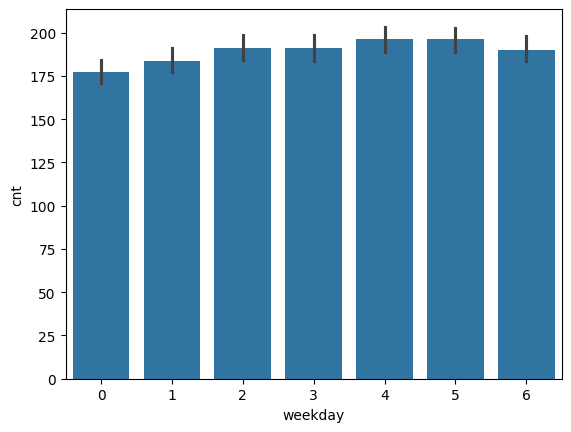

In [9]:
sns.barplot(x="weekday", y="cnt", data=df, estimator=np.mean)
plt.show()

La moyenne des locations varie relativement peu selon le jour de la semaine. Cette vue globale masque toutefois des profils horaires différents.


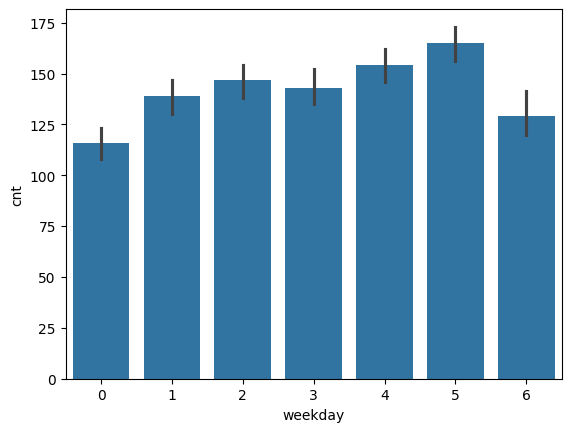

In [10]:
sns.barplot(x="weekday", y="cnt", data=df, estimator=np.median)
plt.show()

La médiane par jour fait apparaître davantage de variation, notamment entre le début de semaine et le week-end.


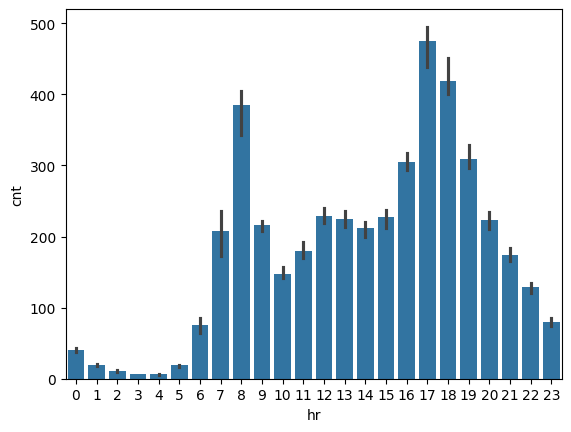

In [11]:
sns.barplot(x="hr", y="cnt", data=df, estimator=np.median)
plt.show()

La demande médiane présente des pics vers **8 h** et **17–18 h**. Ces horaires sont compatibles avec des trajets domicile-travail, sans suffire à établir à eux seuls la cause des déplacements.


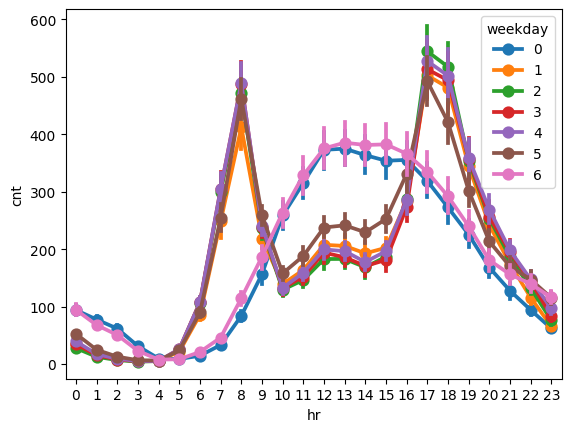

In [12]:
sns.pointplot(data=df, x='hr', y='cnt', hue='weekday')
plt.show()

Le croisement de l'heure et du jour précise ce contraste : les jours ouvrés montrent deux pics, tandis que le week-end suit plutôt une courbe centrée sur le milieu de l'après-midi. L'effet de l'heure dépend donc du type de jour.


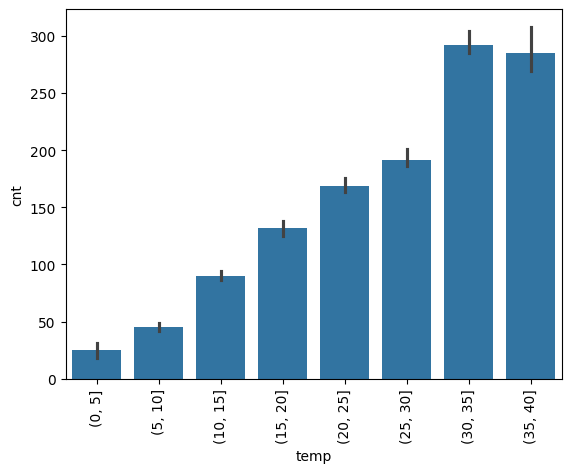

In [13]:
temp_range = range(0, round(df["temp"].max()), 5)
temp_binned = pd.cut(df["temp"], bins=temp_range)
temp_plot = sns.barplot(x=temp_binned, y=df["cnt"], estimator=np.median)
plt.xticks(rotation=90)
plt.show()

Les locations médianes augmentent globalement avec la température dans les intervalles observés. La température est ainsi une variable explicative plausible, même si cette relation descriptive n'établit pas une causalité isolée.


### Saison, météo et autres facteurs


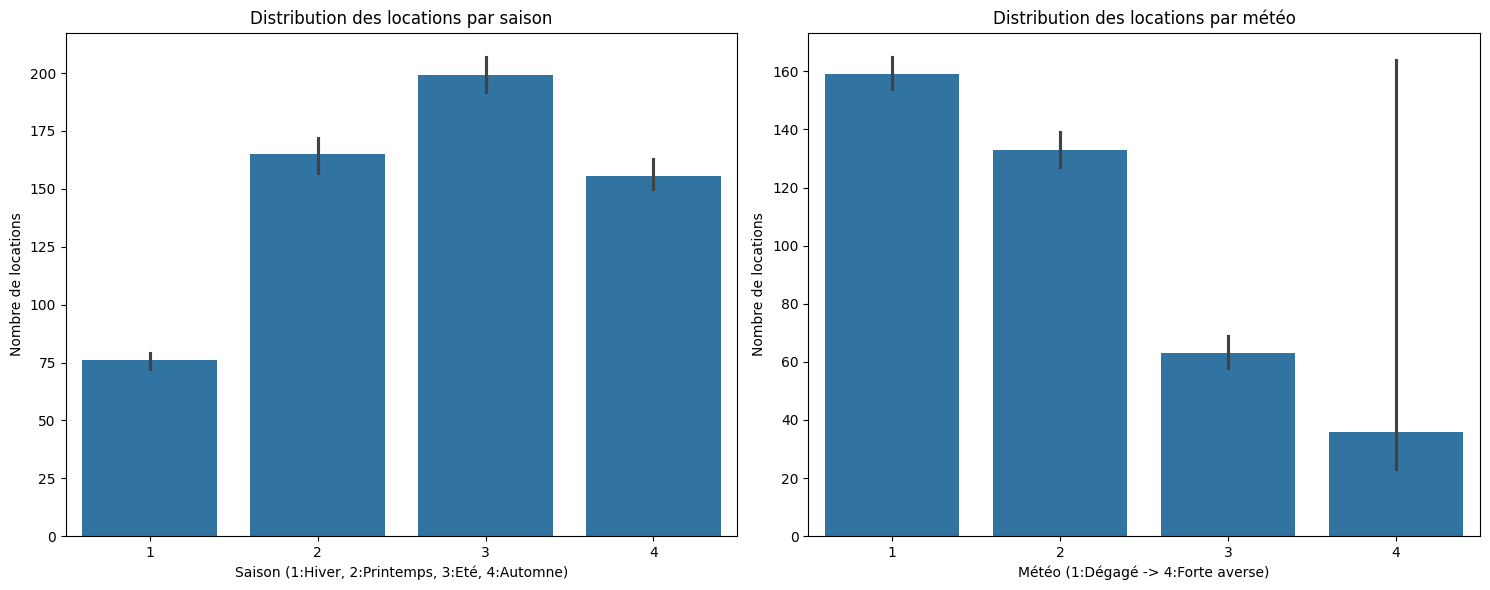

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(x="season", y="cnt", data=df, estimator=np.median, ax=axes[0])
axes[0].set_title('Distribution des locations par saison')
axes[0].set_xlabel('Saison (1:Hiver, 2:Printemps, 3:Eté, 4:Automne)')
axes[0].set_ylabel('Nombre de locations')

sns.barplot(data=df, x='weathersit', y='cnt', estimator=np.median, ax=axes[1])
axes[1].set_title('Distribution des locations par météo')
axes[1].set_xlabel('Météo (1:Dégagé -> 4:Forte averse)')
axes[1].set_ylabel('Nombre de locations')

plt.tight_layout()
plt.show()

La demande médiane diffère selon la saison et diminue quand les conditions météo se dégradent. Le contraste entre les catégories rares doit être lu avec leurs effectifs en tête.


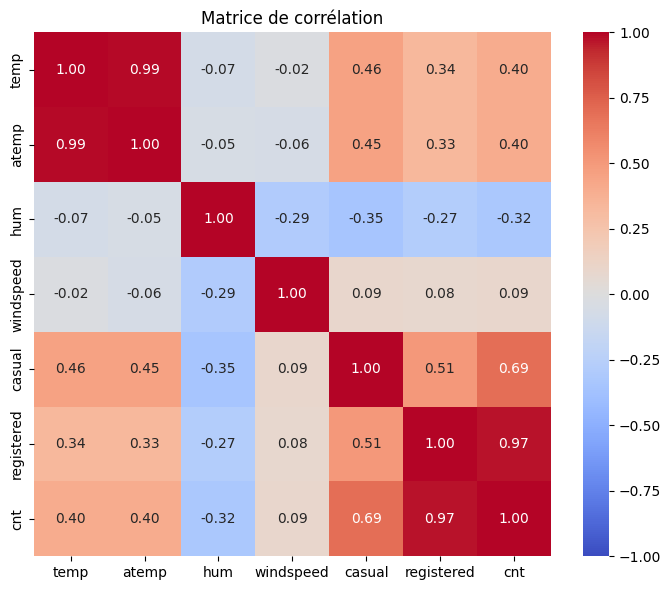

In [15]:
cols_corr = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']

corr_matrix = df[cols_corr].corr()

plt.figure(figsize=(7,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matrice de corrélation')
plt.tight_layout()
plt.show()

La matrice montre une relation positive entre `cnt` et la température, et négative avec l'humidité. `temp` et `atemp` sont presque identiques sur ces relevés (corrélation d'environ **0,99**). `casual` et `registered` sont affichées pour comprendre le total, mais resteront exclues de l'entraînement.


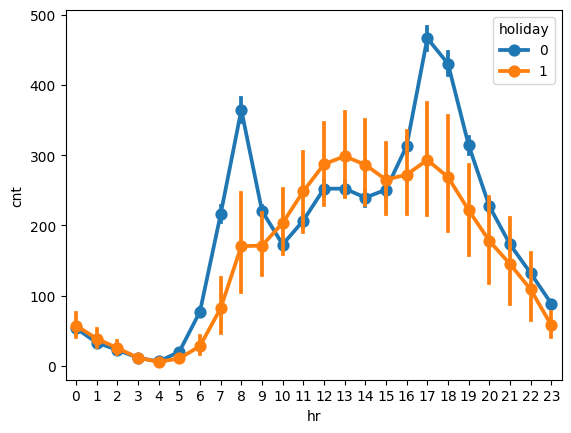

In [16]:
sns.pointplot(data=df, x='hr', y='cnt', hue='holiday')
plt.show()

Les heures marquées par `holiday` ont un profil plus proche des jours de week-end, avec une demande davantage concentrée dans l'après-midi. Il s'agit d'une observation sur ce jeu de données, à confirmer sur d'autres périodes.


## Segmentation non supervisée des conditions météo


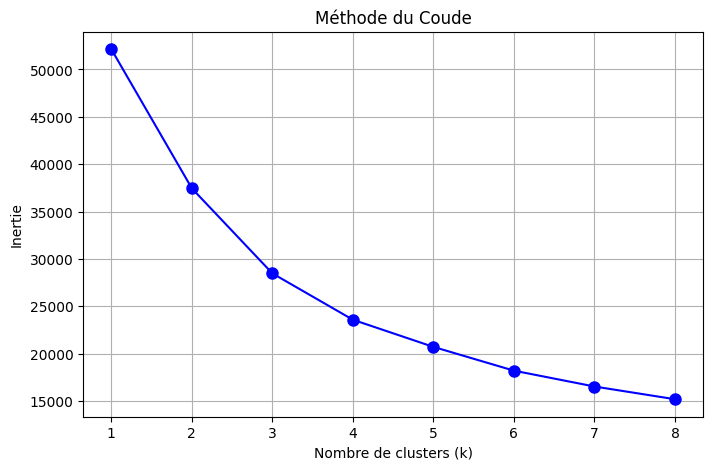

In [17]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
features = ['temp', 'hum', 'windspeed']
df['hum'] = df['hum'].fillna(df['hum'].median())

X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
inertias = []

K_range = range(1, 9)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-', markersize=8)
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Inertie')
plt.title('Méthode du Coude')
plt.grid(True)
plt.show()

L'inertie de K-Means baisse fortement jusqu'à environ **quatre groupes**, puis la réduction ralentit. `k=4` est retenu comme choix exploratoire pour visualiser des profils météo ; la courbe du coude ne prouve pas un nombre de groupes unique ou optimal.


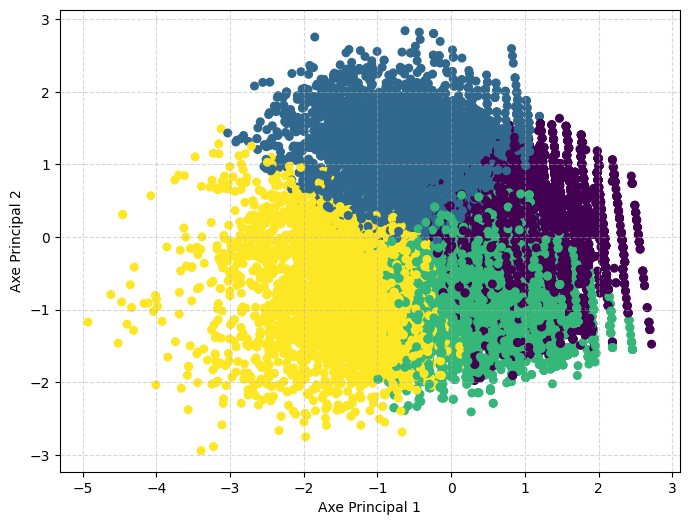

In [18]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

clusters = kmeans.fit_predict(X_scaled)

pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(coords[:, 0], coords[:, 1], c=clusters, s=30)
plt.xlabel('Axe Principal 1')
plt.ylabel('Axe Principal 2')
plt.grid(True, linestyle='--', alpha=0.5)

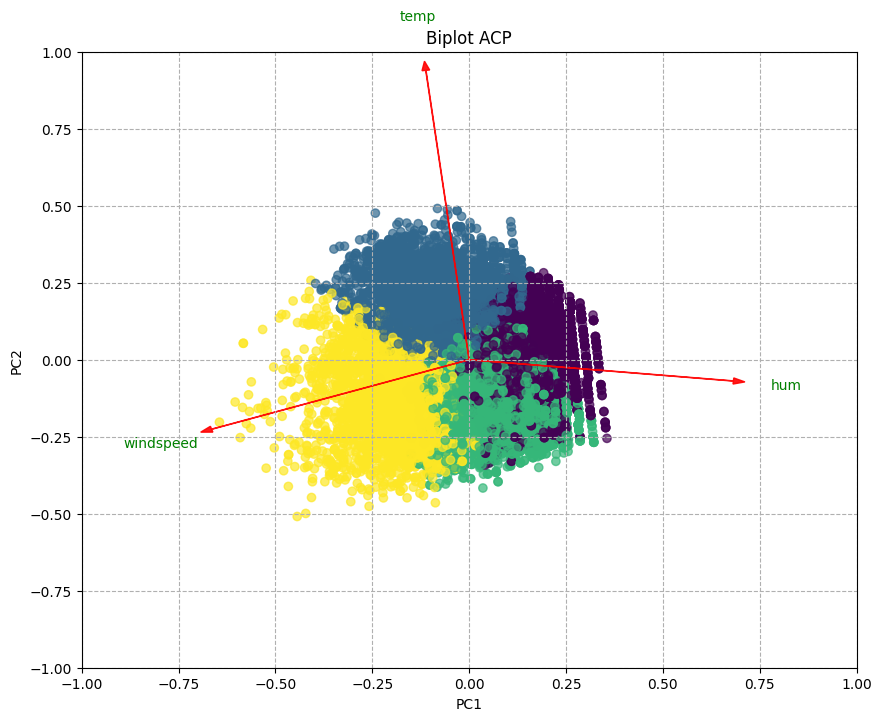

In [19]:
data_sortie= pca.fit_transform(X_scaled)

def biplot(score, coeff, cat=None, cmap="viridis", labels=None):
    xs = score[:,0]
    ys = score[:,1]
    n = coeff.shape[0] 
    

    scalex = 1.0/(xs.max() - xs.min())
    scaley = 1.0/(ys.max() - ys.min())
    
    plt.figure(figsize=(10, 8))
    

    points = plt.scatter(xs * scalex, ys * scaley, c=clusters, cmap=cmap, alpha=0.7)

    for i in range(n):
        plt.arrow(0, 0, coeff[i,0], coeff[i,1], color='r', alpha=0.9, 
                  head_width=0.02, length_includes_head=True)
        
        if labels is None:
            plt.text(coeff[i,0]* 1.15, coeff[i,1] * 1.15, "Var"+str(i+1), 
                     color='g', ha='center', va='center')
        else:
            plt.text(coeff[i,0]* 1.15, coeff[i,1] * 1.15, labels[i], 
                     color='g', ha='center', va='center')

    plt.xlim(-1,1)
    plt.ylim(-1,1)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(linestyle='--')
    plt.title("Biplot ACP")

biplot(score=data_sortie[:,0:2],coeff=np.transpose(pca.components_[0:2, :]),cmap="viridis",labels=features)

plt.show()

Les quatre groupes sont projetés sur deux axes par analyse en composantes principales (ACP). Cette projection permet de lire les regroupements en deux dimensions, sans utiliser `cnt` pour former les clusters.


In [20]:
components_df = pd.DataFrame(
    pca.components_, 
    columns=features, 
    index=['Axe principal 1', 'Axe principal 2']
)
print(components_df.T)

           Axe principal 1  Axe principal 2
temp             -0.115254         0.969262
hum               0.711756        -0.072060
windspeed        -0.692906        -0.235241


Les coefficients de l'ACP aident à interpréter les axes : le premier oppose surtout humidité et vent, tandis que le second est dominé par la température.


Cette segmentation résume différents profils de conditions météo. Elle sert à l'exploration et n'est pas ajoutée aux variables du modèle prédictif final.


## Feature engineering


Deux indicateurs combinent les informations de calendrier : `workingday` identifie les jours de semaine non marqués par `holiday`, et `rush_hour` leurs créneaux de pointe à 8 h, 17 h ou 18 h.


In [21]:
df['workingday'] = df['weekday'].isin([1, 2, 3, 4, 5]) & (df['holiday'] == 0)
df['workingday'] = df['workingday'].astype(int)

df['rush_hour'] = df['workingday'] & df['hr'].isin([8, 17, 18])
df['rush_hour'] = df['rush_hour'].astype("category")
df['workingday'] = df['workingday'].astype("category")

La variable `rush_hour` cherche à capter une interaction entre heure et type de jour qu'une variable d'heure seule ne représenterait pas. Son lien avec `cnt` est examiné par corrélation et par comparaison des distributions.


Corrélation de 'rush_hour' avec 'cnt' : 0.5218

Statistiques comparatives :
           count        mean  median         std
rush_hour                                       
False      15886  160.445361   123.0  148.037777
True        1493  498.221031   501.0  213.380422


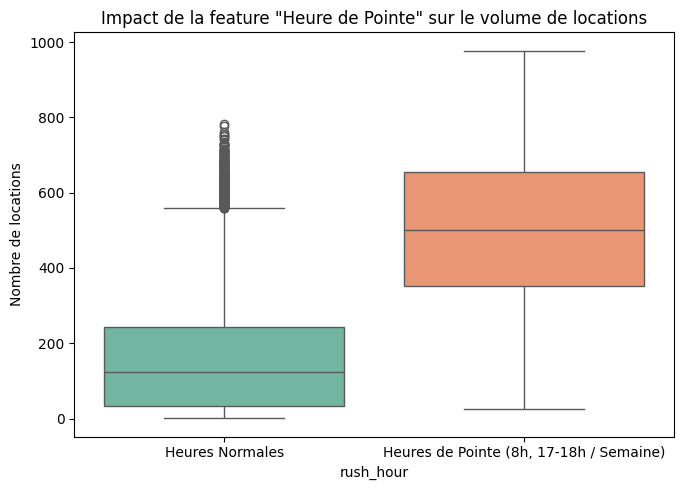

In [22]:
corr_score = df['rush_hour'].astype(int).corr(df['cnt'])

stats = df.groupby('rush_hour', observed=True)['cnt'].agg(['count', 'mean', 'median', 'std'])

print(f"Corrélation de 'rush_hour' avec 'cnt' : {corr_score:.4f}")
print("\nStatistiques comparatives :")
print(stats)

plt.figure(figsize=(7, 5))

sns.boxplot(x='rush_hour', y='cnt', data=df, hue='rush_hour', palette='Set2', legend=False)

plt.title('Impact de la feature "Heure de Pointe" sur le volume de locations')
plt.ylabel('Nombre de locations')
plt.xticks([0, 1], ['Heures Normales', 'Heures de Pointe (8h, 17-18h / Semaine)'])

plt.tight_layout()
plt.show()

## Modélisation et évaluation


### Répartition entraînement et test


In [23]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['instant', 'dteday', 'casual', 'registered', 'atemp', 'cnt'])
y = df['cnt']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Entraînement : {X_train.shape[0]}")
print(f"Test : {X_test.shape[0]}")

Entraînement : 13903
Test : 3476


Une séparation aléatoire réserve **20 %** des observations au test, avec une graine fixe pour reproduire la comparaison. Ce protocole mesure une généralisation sur des heures mélangées ; une prévision d'heures futures nécessiterait une validation chronologique.


### Régression linéaire : modèle de référence


In [24]:
from sklearn.linear_model import LinearRegression
df['hum'] = df['hum'].fillna(df['hum'].median())

cols_categ = ['season', 'weathersit', 'mnth', 'hr', 'weekday', 'holiday', 'workingday', 'rush_hour']
X = pd.get_dummies(df[cols_categ].astype(str), drop_first=True)

X = pd.concat([X, df[['temp', 'hum', 'windspeed']]], axis=1)

y = np.log(df['cnt'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

La régression linéaire fournit un point de comparaison simple et interprétable. Les catégories sont encodées et la cible est transformée par `log(cnt)` afin de réduire l'écart entre faibles et fortes demandes. Les prédictions sont ensuite ramenées à l'échelle du nombre de locations pour calculer la RMSE.


### Mesure des performances


In [25]:
from sklearn.metrics import mean_squared_error, r2_score

rmse = np.sqrt(mean_squared_error(np.exp(y_test), np.exp(y_pred)))
r2 = r2_score(y_test, y_pred)

print(f"R² : {r2:.4f}")
print(f"RMSE : {rmse:.2f}")

R² : 0.8056
RMSE : 103.75


La régression linéaire obtient un **R² de 0,8056** sur la cible logarithmique et une **RMSE de 103,75 locations** sur l'échelle d'origine. L'erreur peut être particulièrement gênante pendant les heures creuses ; le score global ne remplace pas une analyse des résidus par plage horaire.

### XGBoost : relations non linéaires


In [26]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=1000,   
    learning_rate=0.05,  
    max_depth=6,         
    n_jobs=-1,           
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred)))
r2 = r2_score(y_test, y_pred)

print(f"R² : {r2:.4f}")      
print(f"RMSE : {rmse:.2f}")  

R² : 0.9086
RMSE : 71.08


XGBoost capture des interactions et des relations non linéaires que la régression linéaire décrit moins bien ici. Sur le même test, la RMSE passe de **103,75** à **71,08 locations**, et le R² de **0,8056** à **0,9086**.


## Régularisation et optimisation


### Régularisation L2 de XGBoost


In [27]:
model2 = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    n_jobs=-1,
    random_state=42,
    reg_lambda=10.0  
)

model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)

rmse = np.sqrt(mean_squared_error(np.exp(y_test), np.exp(y_pred2)))
r2 = r2_score(y_test, y_pred2)

print(f"R² (avec L2) : {r2:.4f}")
print(f"RMSE (avec L2) : {rmse:.2f}")

R² (avec L2) : 0.9112
RMSE (avec L2) : 70.67


Le paramètre `reg_lambda` ajoute une pénalité L2 aux poids des feuilles de XGBoost afin de limiter la complexité du modèle. Il est évalué sur le même jeu de test que le modèle précédent.


La régularisation apporte une amélioration modeste : **R² 0,9112** et **RMSE 70,67**, contre 0,9086 et 71,08 sans cette pénalité.


### Recherche d'hyperparamètres avec FLAML


In [28]:
from flaml import AutoML

automl = AutoML()

settings = {
    "time_budget": 120,
    "metric": 'rmse',
    "task": 'regression',
    "estimator_list": ['xgboost'],
    "verbose": 0,
}

automl.fit(X_train=X_train, y_train=y_train, **settings)

print("Meilleurs hyperparamètres :", automl.best_config)

y_pred_best = automl.predict(X_test)

rmse_best = np.sqrt(mean_squared_error(np.exp(y_test), np.exp(y_pred_best)))
r2_best = r2_score(y_test, y_pred_best)

print(f"R² : {r2_best:.4f}")
print(f"RMSE : {rmse_best:.2f} vélos")

Meilleurs hyperparamètres : {'n_estimators': 5127, 'max_leaves': 173, 'min_child_weight': 128.0, 'learning_rate': np.float64(0.08383187944806188), 'subsample': np.float64(0.8741470179786065), 'colsample_bylevel': np.float64(0.8165609218772506), 'colsample_bytree': np.float64(0.6361201081532135), 'reg_alpha': np.float64(0.15337522029428585), 'reg_lambda': np.float64(0.3356216115074585)}


R² : 0.9250
RMSE : 67.91 vélos


FLAML explore pendant **120 secondes** des configurations XGBoost, notamment le taux d'apprentissage, la taille des arbres, l'échantillonnage et les pénalités. Le temps limité rend le choix pratique mais aussi sensible aux conditions d'exécution.


Sur l'exécution conservée, la configuration retenue atteint **R² 0,9250** et **RMSE 67,91 locations**. Une nouvelle recherche limitée dans le temps peut sélectionner d'autres paramètres et produire un score légèrement différent.


## Limites et perspectives


Le modèle estime une demande agrégée, sans préciser quelles stations ou bornes auront besoin de vélos ou de maintenance. Une planification locale demanderait des données de localisation, de capacité, de stock disponible et d'incidents. Pour évaluer réellement une prévision future, il faudrait aussi séparer les données dans l'ordre chronologique et ajuster l'imputation uniquement sur l'entraînement.


Des modèles de séries temporelles, comme SARIMA, pourraient exploiter explicitement les cycles horaires et saisonniers. Leur intérêt devrait être comparé à une référence solide avant d'ajouter de la complexité.
